# S5 · Temporal and segment heterogeneity

Heterogeneity is treated as descriptive and exploratory. BH-adjusted q-values and global screens are reported, but subgroup rankings are not used to target borrowers or claim stable causal differences.

In [1]:
from pathlib import Path
import json, time
import pandas as pd
import numpy as np
import psutil
from IPython.display import display, Image

ROOT = Path.cwd().parent
OUTPUTS = ROOT / "outputs"
AUDIT = ROOT / "audit"
LOGS = ROOT / "logs"
LOGS.mkdir(exist_ok=True)
RUN_LOG = LOGS / "run_log.txt"

def checkpoint(label, *frames, started=None):
    elapsed = time.time() - started if started is not None else 0.0
    shapes = [getattr(x, "shape", None) for x in frames]
    nulls = []
    for frame in frames:
        if hasattr(frame, "isna"):
            nulls.append(round(float(frame.isna().mean(numeric_only=False).mean()), 6))
    rss = psutil.Process().memory_info().rss / 1024**3
    line = f"{label} | shapes={shapes} | mean_null_rates={nulls} | rss_gib={rss:.3f} | elapsed_s={elapsed:.3f}"
    print(line)
    with RUN_LOG.open("a", encoding="utf-8") as stream:
        stream.write(line + "\n")

t0 = time.time()
print(f"Audit root: {ROOT}")
checkpoint("setup", started=t0)

Audit root: <PROJECT_ROOT>/5_最终交付包/_rebuild/MA-Hackathon-Final-2026-09-04
setup | shapes=[] | mean_null_rates=[] | rss_gib=0.113 | elapsed_s=0.000


In [2]:
t0 = time.time()
years = pd.read_csv(OUTPUTS / "rq3_year_effects.csv")
year_global = pd.read_csv(OUTPUTS / "rq3_global_tests.csv")
sectors = pd.read_csv(OUTPUTS / "rq4_sector_effects.csv")
countries = pd.read_csv(OUTPUTS / "rq4_country_effects.csv")
display(year_global)
display(years)
display(sectors.head(30))
display(countries.head(30))
checkpoint("S5 heterogeneity tables", years, year_global, sectors, countries, started=t0)

,dimension,channel,groups_tested,q_statistic,degrees_of_freedom,p_value,method,limitation
0,year,current,9,56.360569,8,2.399593e-09,inverse-variance Wald/Q screen across non-over...,does not estimate cross-group covariance from ...
1,year,recent,9,23.481125,8,2.798456e-03,inverse-variance Wald/Q screen across non-over...,does not estimate cross-group covariance from ...


,dimension,group,channel,term,estimate,std_error,ci_low,ci_high,p_value,scenario_percent_change,scenario_ci_low,scenario_ci_high,scenario_unit,n,vcov,q_value_bh
0,year,2016,current,CH,0.035035,0.059595,-0.085610,0.155679,5.600954e-01,70.404885,40.409602,106.807971,percent change in conditional geometric mean o...,102466,country + week two-way CRV1,5.600954e-01
1,year,2016,recent,VG,0.004681,0.013978,-0.023617,0.032979,7.395446e-01,37.152144,9.045726,72.502961,percent change in conditional geometric mean o...,102466,country + week two-way CRV1,8.319877e-01
2,year,2017,current,CH,0.041064,0.049176,-0.058487,0.140616,4.089109e-01,59.302768,32.766231,91.143272,percent change in conditional geometric mean o...,153560,country + week two-way CRV1,4.600248e-01
3,year,2017,recent,VG,0.041839,0.028135,-0.015117,0.098794,1.452461e-01,35.386020,13.259828,61.834737,percent change in conditional geometric mean o...,153560,country + week two-way CRV1,2.269470e-01
4,year,2018,current,CH,0.430884,0.102995,0.222197,0.639571,1.692614e-04,264.880179,137.399532,460.816374,percent change in conditional geometric mean o...,145008,country + week two-way CRV1,5.077841e-04
5,year,2018,recent,VG,-0.150569,0.102759,-0.358778,0.057641,1.512980e-01,13.062645,-18.776058,57.381696,percent change in conditional geometric mean o...,145008,country + week two-way CRV1,2.269470e-01
6,year,2019,current,CH,0.029774,0.025702,-0.022459,0.082006,2.547595e-01,88.771124,61.515124,120.626630,percent change in conditional geometric mean o...,133897,country + week two-way CRV1,3.275479e-01
7,year,2019,recent,VG,-0.053361,0.018536,-0.091032,-0.015691,6.857995e-03,25.642851,9.304686,44.423140,percent change in conditional geometric mean o...,133897,country + week two-way CRV1,6.172195e-02
8,year,2020,current,CH,0.026692,0.021090,-0.016216,0.069601,2.145132e-01,74.469666,53.254888,98.621164,percent change in conditional geometric mean o...,127092,country + week two-way CRV1,3.217698e-01
9,year,2020,recent,VG,-0.066652,0.033811,-0.135442,0.002138,5.712348e-02,-18.549275,-34.115719,0.695044,percent change in conditional geometric mean o...,127092,country + week two-way CRV1,1.874850e-01


,dimension,group,channel,term,estimate,std_error,ci_low,ci_high,p_value,scenario_percent_change,scenario_ci_low,scenario_ci_high,scenario_unit,n,vcov,q_value_bh
0,sector,Agriculture,current,CH,-0.018120,0.181229,-0.384397,0.348157,9.208556e-01,58.678610,19.353477,110.960769,percent change in conditional geometric mean o...,402595,country + week two-way CRV1,0.920856
1,sector,Agriculture,recent,VG,0.407652,0.205382,-0.007440,0.822744,5.404903e-02,-30.111087,-51.387303,0.477046,percent change in conditional geometric mean o...,402595,country + week two-way CRV1,0.094586
2,sector,Food,current,CH,0.280499,0.216497,-0.156724,0.717723,2.023504e-01,337.272475,188.854484,561.949972,percent change in conditional geometric mean o...,259893,country + week two-way CRV1,0.314767
3,sector,Food,recent,VG,0.932713,0.338073,0.249960,1.615466,8.627005e-03,-41.728382,-58.232802,-18.702196,percent change in conditional geometric mean o...,259893,country + week two-way CRV1,0.030195
4,sector,Retail,current,CH,0.043524,0.047868,-0.053298,0.140347,3.688037e-01,70.165840,21.333697,138.651039,percent change in conditional geometric mean o...,235331,country + week two-way CRV1,0.469387
5,sector,Retail,recent,VG,0.260167,0.060248,0.138303,0.382030,1.045544e-04,15.230176,-1.934480,35.399204,percent change in conditional geometric mean o...,235331,country + week two-way CRV1,0.001464
6,sector,Housing,current,CH,-0.091712,0.013430,-0.119371,-0.064053,3.703824e-07,27.019083,9.150576,47.812755,percent change in conditional geometric mean o...,74031,country + week two-way CRV1,0.000005
7,sector,Housing,recent,VG,0.026243,0.023571,-0.022302,0.074788,2.761353e-01,11.328567,-4.317371,29.532915,percent change in conditional geometric mean o...,74031,country + week two-way CRV1,0.322158
8,sector,Services,current,CH,0.831403,0.442738,-0.064873,1.727680,6.808983e-02,154.458285,-27.602527,794.354673,percent change in conditional geometric mean o...,55098,country + week two-way CRV1,0.136180
9,sector,Services,recent,VG,0.528980,0.433587,-0.348772,1.406731,2.299798e-01,-8.678617,-66.507593,148.999576,percent change in conditional geometric mean o...,55098,country + week two-way CRV1,0.292702


,dimension,group,channel,term,estimate,std_error,ci_low,ci_high,p_value,scenario_percent_change,scenario_ci_low,scenario_ci_high,scenario_unit,n,vcov,q_value_bh
0,country,Philippines,current,CH,0.034633,0.013820,0.007472,0.061793,1.256471e-02,90.654672,75.755830,106.816490,percent change in conditional geometric mean o...,430016,week CRV1 within country,1.449774e-02
1,country,Philippines,recent,VG,0.040644,0.017087,0.007063,0.074224,1.779345e-02,12.385928,0.498831,25.679042,percent change in conditional geometric mean o...,430016,week CRV1 within country,5.189347e-02
2,country,Kenya,current,CH,0.151918,0.027645,0.097593,0.206244,6.462700e-08,97.328274,76.239120,120.941003,percent change in conditional geometric mean o...,231218,week CRV1 within country,2.967286e-07
3,country,Kenya,recent,VG,-0.033091,0.029230,-0.090532,0.024350,2.581940e-01,-12.493825,-21.484861,-2.473194,percent change in conditional geometric mean o...,231218,week CRV1 within country,3.227425e-01
4,country,Tajikistan,current,CH,0.090738,0.024610,0.042376,0.139100,2.538928e-04,159.297707,135.371977,185.655505,percent change in conditional geometric mean o...,61053,week CRV1 within country,4.231547e-04
5,country,Tajikistan,recent,VG,0.002612,0.035929,-0.067993,0.073218,9.420671e-01,-20.774660,-28.439686,-12.288612,percent change in conditional geometric mean o...,61053,week CRV1 within country,9.438381e-01
6,country,Uganda,current,CH,0.066267,0.013755,0.039236,0.093298,1.976667e-06,44.188197,33.736462,55.456752,percent change in conditional geometric mean o...,57292,week CRV1 within country,4.941669e-06
7,country,Uganda,recent,VG,0.079097,0.035306,0.009714,0.148479,2.554975e-02,-2.804699,-12.700712,8.213099,percent change in conditional geometric mean o...,57292,week CRV1 within country,5.474946e-02
8,country,Cambodia,current,CH,0.085760,0.015529,0.055236,0.116283,5.847081e-08,52.354276,33.487905,73.887106,percent change in conditional geometric mean o...,54225,week CRV1 within country,2.967286e-07
9,country,Cambodia,recent,VG,0.103798,0.016779,0.070818,0.136779,1.457841e-09,7.520609,-3.580031,19.899243,percent change in conditional geometric mean o...,54225,week CRV1 within country,2.186761e-08


S5 heterogeneity tables | shapes=[(18, 16), (2, 8), (28, 16), (30, 16)] | mean_null_rates=[0.0, 0.0, 0.0, 0.0] | rss_gib=0.114 | elapsed_s=0.022


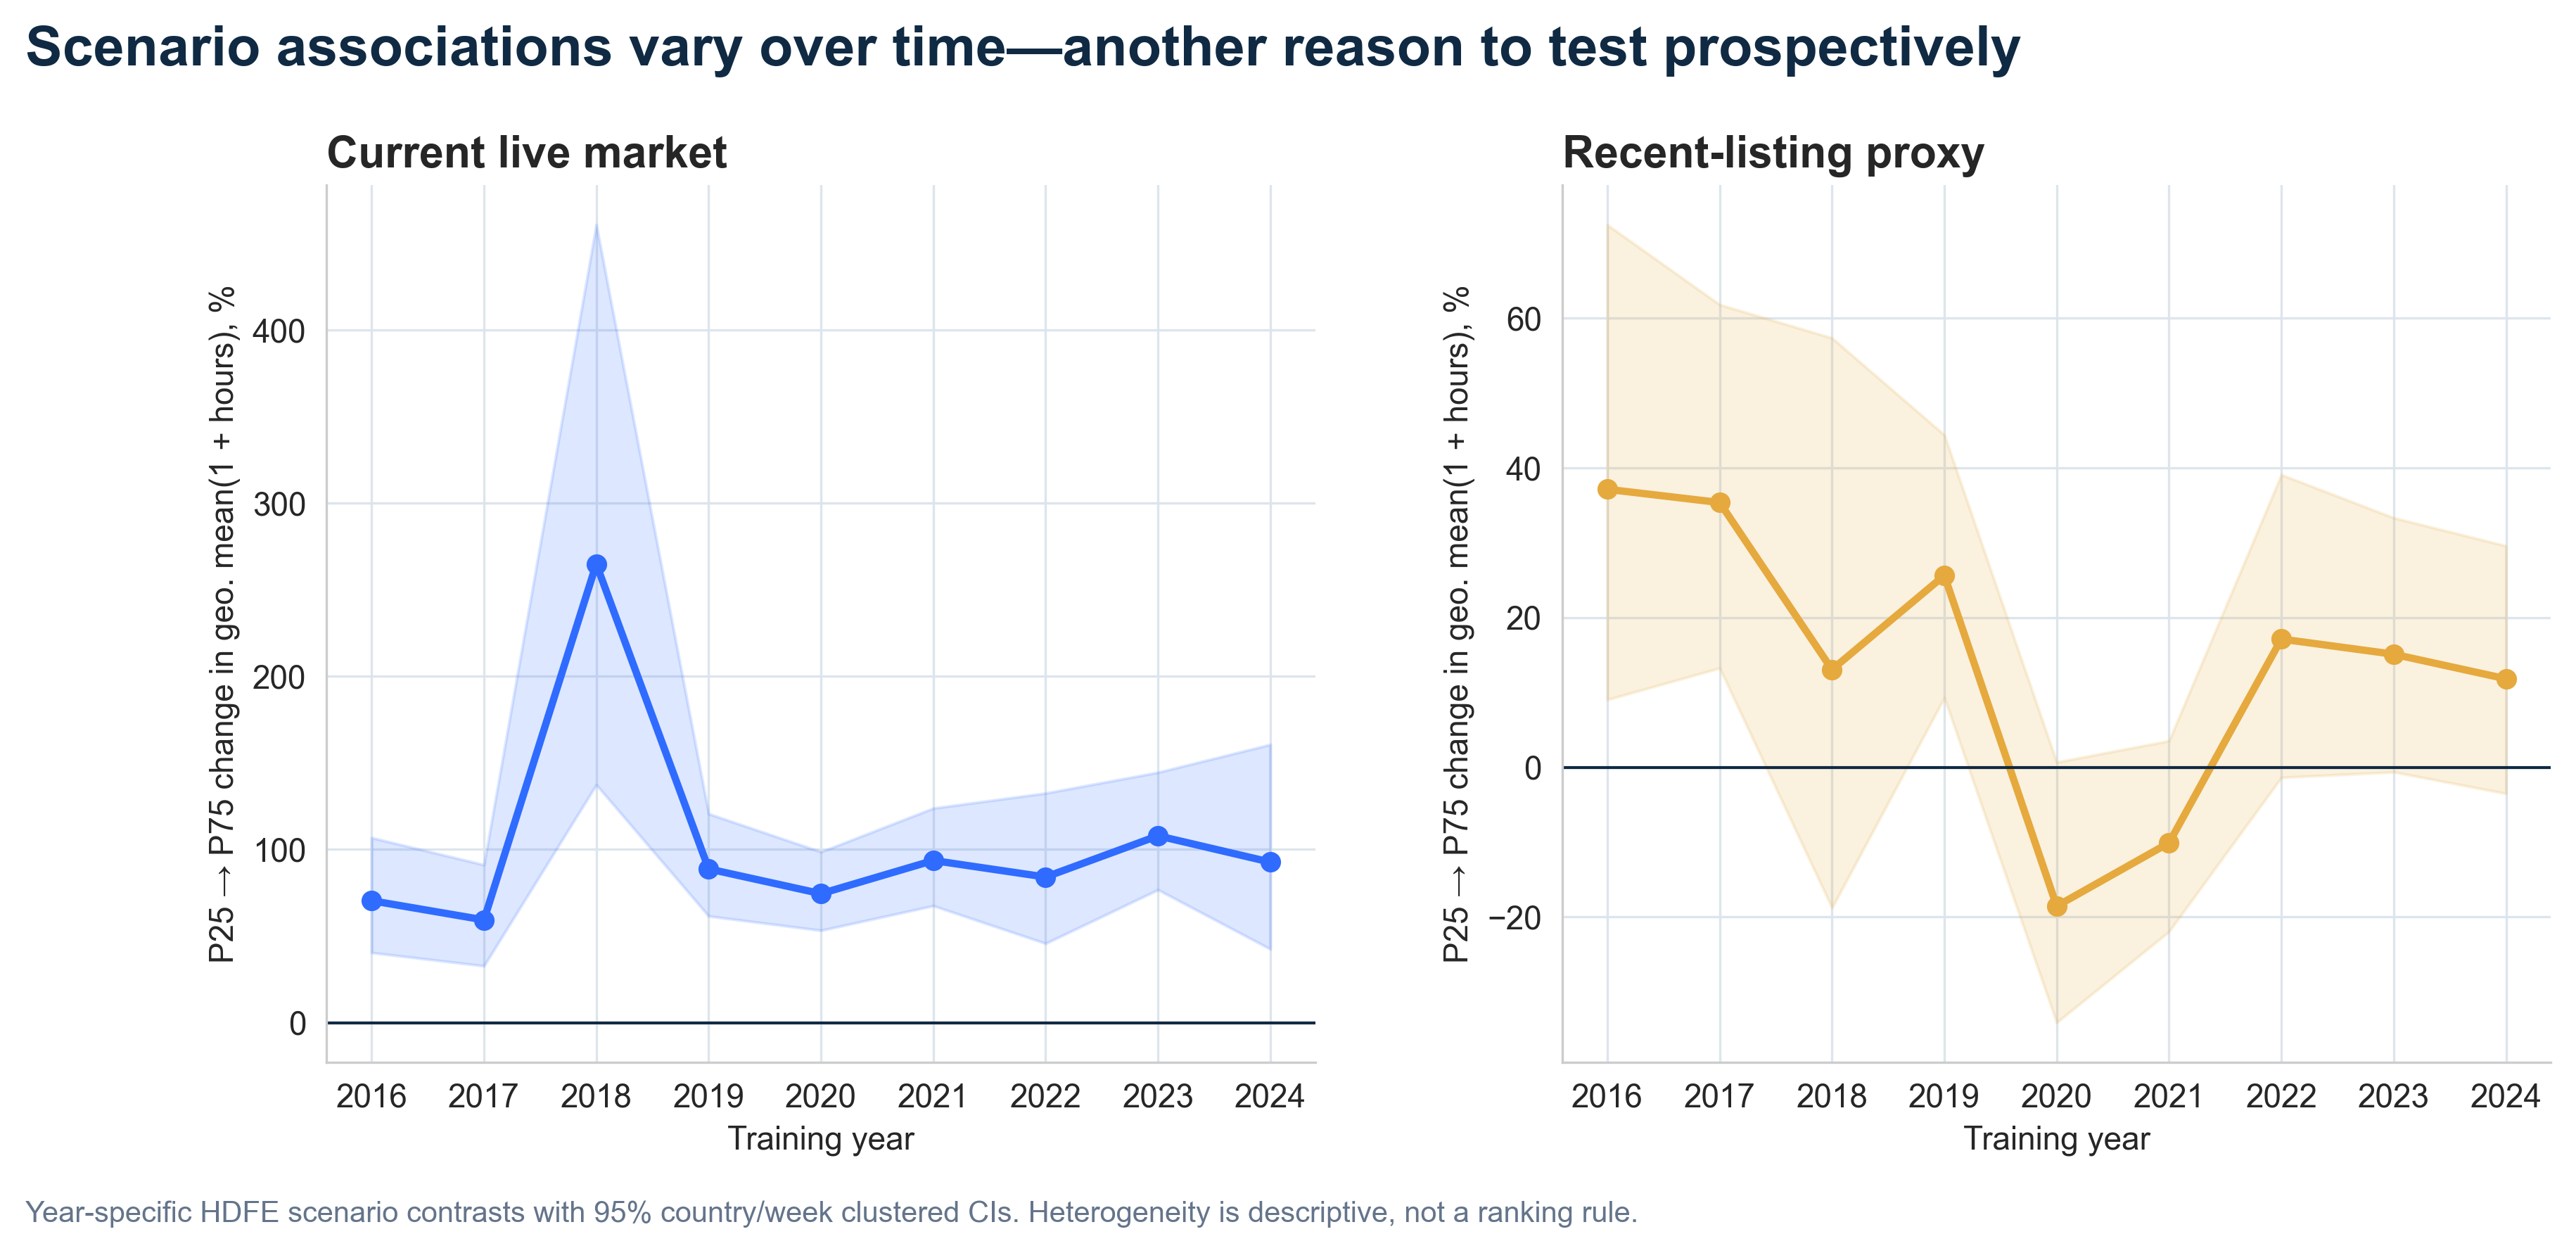

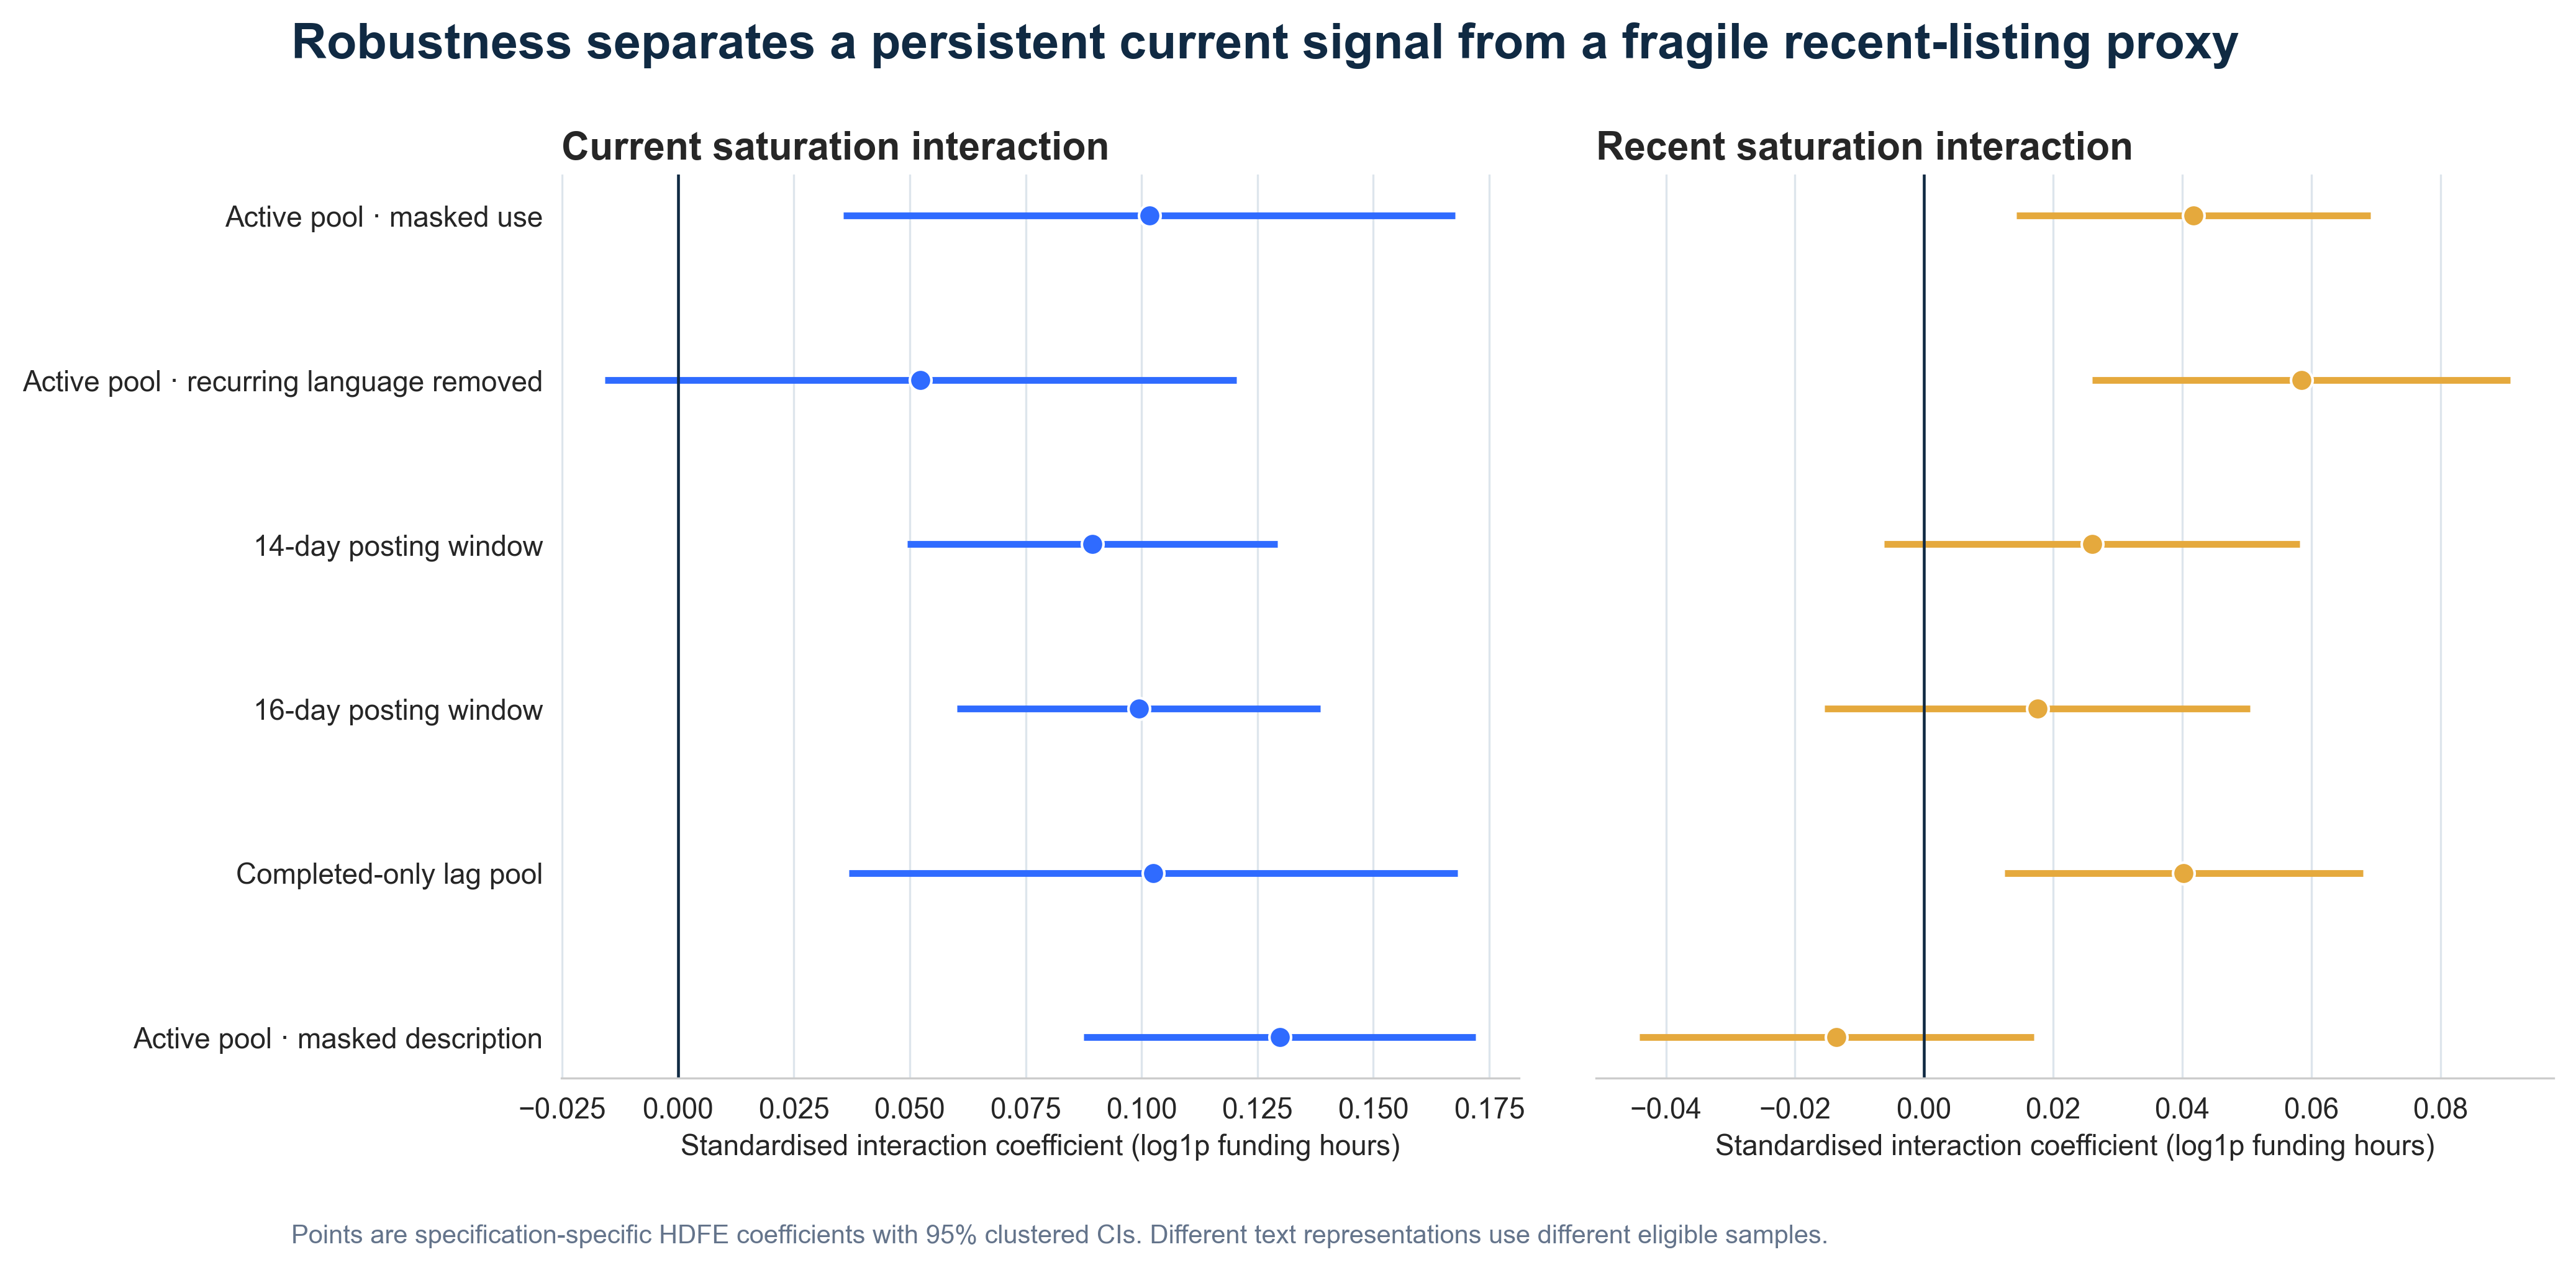

Visuals are paired with source CSV files under figures/source_data/.
S5 rendered figures | shapes=[(18, 16)] | mean_null_rates=[0.0] | rss_gib=0.116 | elapsed_s=0.005


In [3]:
t0 = time.time()
display(Image(filename=str(ROOT / "figures" / "fig03_year_scenarios.png"), width=1000))
display(Image(filename=str(ROOT / "figures" / "fig02_specification_forest.png"), width=1000))
print("Visuals are paired with source CSV files under figures/source_data/.")
checkpoint("S5 rendered figures", years, started=t0)